# **IMPORT LIBERARIES**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Graph Style
sns.set(style="whitegrid")

# **LOADING DATASET**

In [7]:
df = pd.read_csv("/netflix_titles.csv")

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [11]:
df.shape

(8807, 12)

In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna("Unknown")

# **Cleaning Dataset**

In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [18]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [19]:
df.rename(columns={
    "listed_in":"genre",
    "release_year":"release_year"
}, inplace=True)

# **Statistics**:

In [20]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [21]:
df.mean(numeric_only=True)

,0
release_year,2014.180198


In [22]:
df.median(numeric_only=True)

,0
release_year,2017.0


In [23]:
df.mode().head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,#Alive,Unknown,Unknown,United States,2020-01-01,2018.0,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
1,s10,NaN,#AnneFrank - Parallel Stories,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,s100,NaN,#FriendButMarried,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3,s1000,NaN,#FriendButMarried 2,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
4,s1001,NaN,#Roxy,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [24]:
df.std(numeric_only=True)

,0
release_year,8.819312


In [25]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,release_year
release_year,1.0


# **1) Histogram**

> Add blockquote



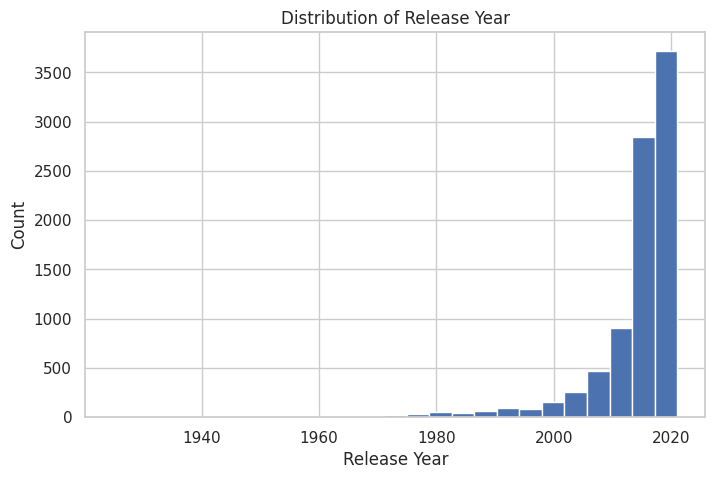

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df['release_year'], bins=25)
plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

# **# 2) Count Plot**

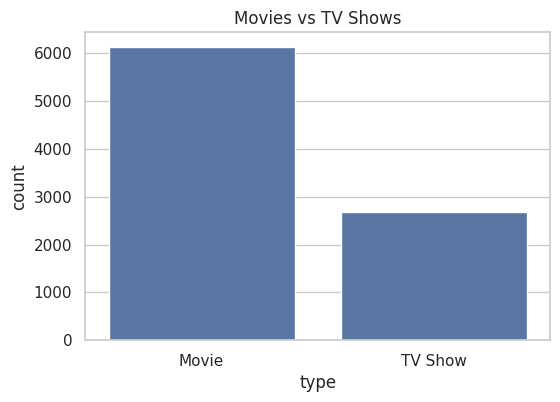

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

# **3) Bar Chart**

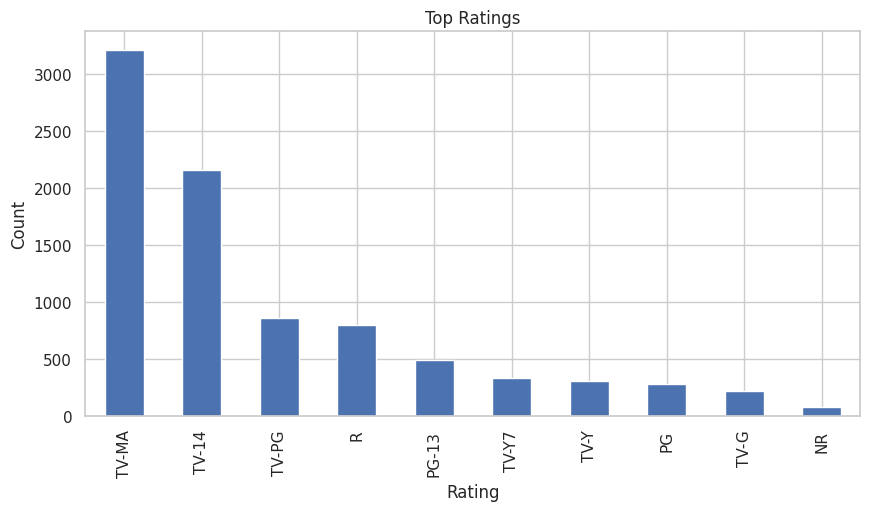

In [30]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title("Top Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**4) Pie Chart**

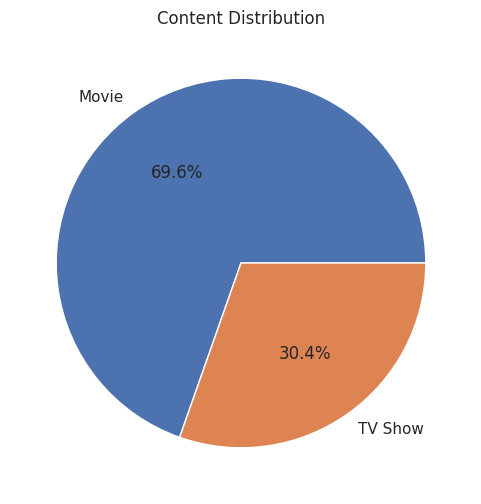

In [31]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Content Distribution")
plt.ylabel("")
plt.show()

# **5) Scatter Plot**




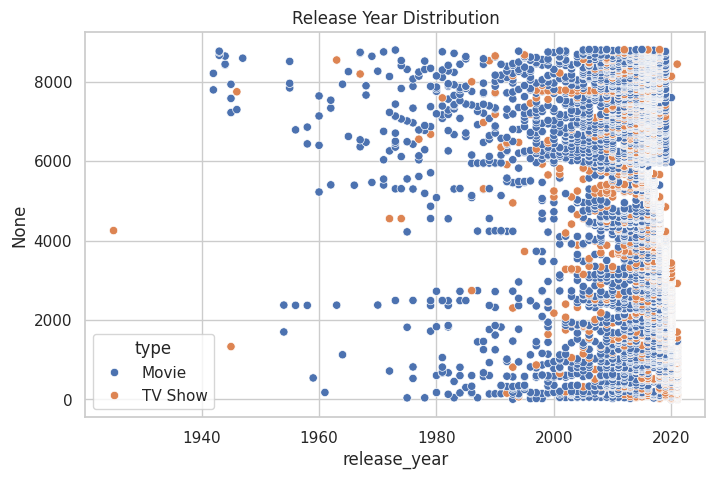

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='release_year',
    y=df.index,
    hue='type',
    data=df
)

plt.title("Release Year Distribution")
plt.show()

# **6) Box Plot**

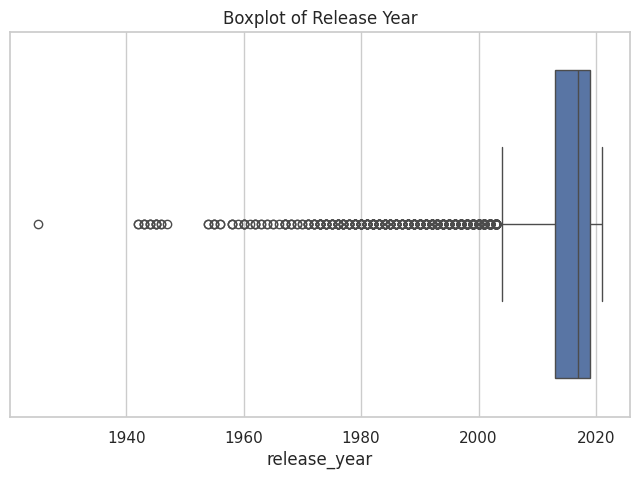

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['release_year'])

plt.title("Boxplot of Release Year")
plt.show()

# **7) Heatmap**

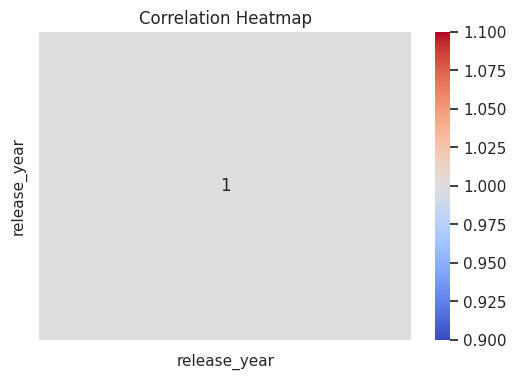

In [34]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# **8) Line Chart**

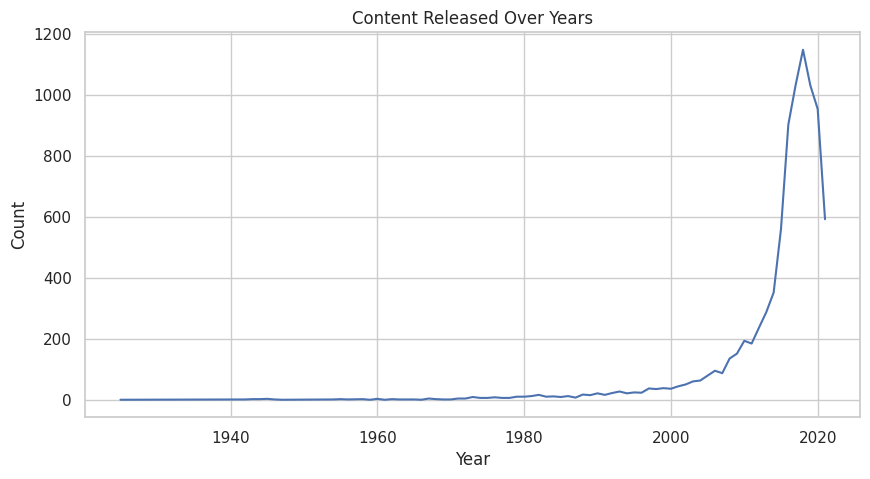

In [35]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)

plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# **9) Violin Plot**

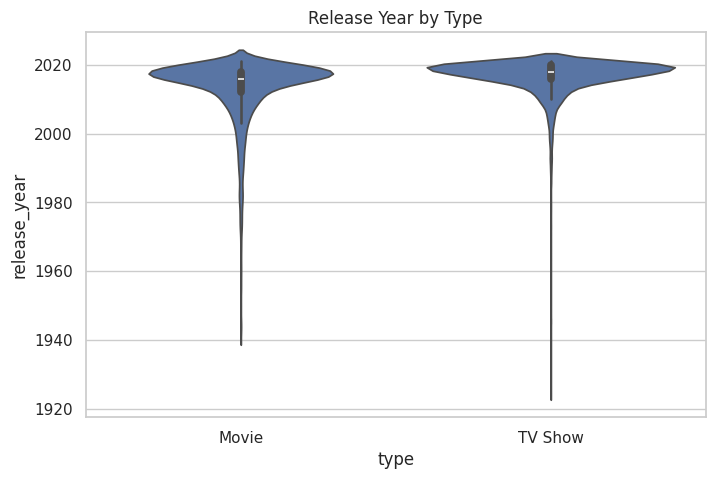

In [36]:
plt.figure(figsize=(8,5))

sns.violinplot(x='type', y='release_year', data=df)

plt.title("Release Year by Type")
plt.show()

# **10) Pair Plot**

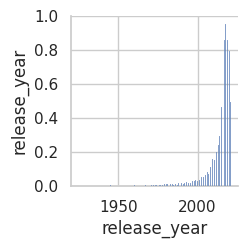

In [37]:
sns.pairplot(numeric_df)
plt.show()

# **INSIGHTS**

# Observation 1

*   Movies are significantly more numerous than TV Shows.


# Observation 2

*   Most content was released after 2015.

# Observation 3

*   TV-MA is the most common rating.

# Observation 4

*   The dataset contains content from many    countries.

# Observation 5

*   Some directors have produced multiple Netflix titles.

# Observation 6

*   There are only a few missing values after cleaning.

# Observation 7

*   Duplicate records were removed successfully.

# Observation 8

*   The release year has a wide distribution.

# Observation 9

*   The correlation matrix shows very weak relationships because there are few numeric variables.

# Observation 10

*   Netflix has rapidly increased its content library in recent years.